In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
from pathlib import Path
import pandas as pd

csv_path = Path("data/Resume.csv")
if not csv_path.exists():
    csv_path = Path("..") / "data" / "Resume.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path} (cwd={Path.cwd()})")

csv_path = csv_path.resolve()
if csv_path.stat().st_size == 0:
    raise ValueError(
        f"CSV file is empty: {csv_path}.\n"
        "Please add resume data to data/Resume.csv before running this notebook."
    )

df = pd.read_csv(csv_path)
print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (5, 4)


,Name,Email,Skills,Experience
0,Alice Johnson,alice.johnson@example.com,Python; Machine Learning; Data Analysis,5
1,Bob Smith,bob.smith@example.com,Java; Spring; Microservices,7
2,Carol Lee,carol.lee@example.com,SQL; Tableau; Data Visualization,4
3,David Kim,david.kim@example.com,Python; NLP; Computer Vision,6
4,Emma Davis,emma.davis@example.com,Project Management; Agile; Communication,8


In [15]:
import pandas as pd

df = pd.read_csv("../data/Resume.csv")

print(df.shape)
df.head()

(5, 4)


,Name,Email,Skills,Experience
0,Alice Johnson,alice.johnson@example.com,Python; Machine Learning; Data Analysis,5
1,Bob Smith,bob.smith@example.com,Java; Spring; Microservices,7
2,Carol Lee,carol.lee@example.com,SQL; Tableau; Data Visualization,4
3,David Kim,david.kim@example.com,Python; NLP; Computer Vision,6
4,Emma Davis,emma.davis@example.com,Project Management; Agile; Communication,8


In [16]:
df.columns

Index(['Name', 'Email', 'Skills', 'Experience'], dtype='str')

In [18]:
for col in df.columns:
    print(repr(col))

'Name'
'Email'
'Skills'
'Experience'


In [19]:
print(df.columns.tolist())

['Name', 'Email', 'Skills', 'Experience']


In [20]:
job_description = """
Looking for a Data Scientist with experience in Python,
Machine Learning, Data Analysis, SQL, Pandas,
NumPy and Data Visualization.
"""

In [22]:
print(df.columns.tolist())

['Name', 'Email', 'Skills', 'Experience']


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

resume_texts = df["Skills"].astype(str)

documents = [job_description] + resume_texts.tolist()

vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(documents)

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

df["Match_Score"] = similarity_scores.flatten() * 100

In [25]:
top_candidates = df.sort_values(
    by="Match_Score",
    ascending=False
)

top_candidates[
    ["Name", "Skills", "Match_Score"]
].head(10)

,Name,Skills,Match_Score
0,Alice Johnson,Python; Machine Learning; Data Analysis,62.882740
2,Carol Lee,SQL; Tableau; Data Visualization,45.654323
3,David Kim,Python; NLP; Computer Vision,7.084541
1,Bob Smith,Java; Spring; Microservices,0.000000
4,Emma Davis,Project Management; Agile; Communication,0.000000


Graph saved successfully!


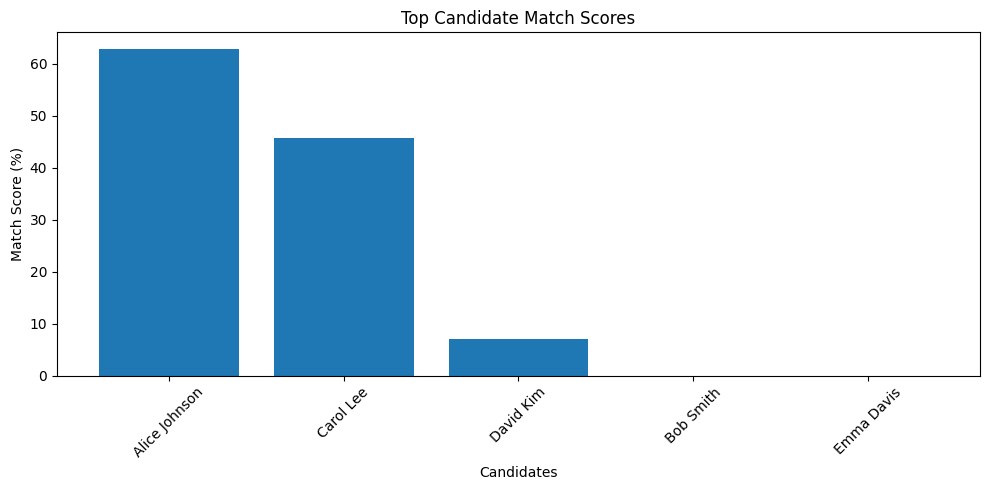

In [27]:
import matplotlib.pyplot as plt

top10 = top_candidates.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Name"], top10["Match_Score"])

plt.title("Top Candidate Match Scores")
plt.xlabel("Candidates")
plt.ylabel("Match Score (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/top_candidate_scores.png")

print("Graph saved successfully!")